# Assignment 1
## Predicting Online Shopper Purchase Intention

### Business Problem

How can an e-commerce business predict whether a website visitor is likely to make a purchase?

## Business Objective

The objective of this project is to analyze online shopping session data and build a machine learning model that can predict whether a website visitor will make a purchase.

This can help an e-commerce business better understand customer behavior and identify visitors who are more likely to purchase products.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the online shopping dataset
df = pd.read_csv("online_shoppers_intention.csv")

In [5]:
# Display the first 5 rows of the dataset
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
# Check the number of rows and columns in the dataset
df.shape


(12330, 18)

In [7]:
# Display information about the dataset
# This shows the column names, data types, and number of non-empty values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [8]:
# Display basic statistical information for numerical columns
df.describe()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [9]:
# Check how many missing values are present in each column
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [10]:
# Check how many duplicate rows are present in the dataset
df.duplicated().sum()


125

In [11]:
# Create a copy of the original dataset
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Check the new number of rows and columns
df_clean.shape

(12205, 18)

In [12]:
# Count how many visitors made a purchase and how many did not
df_clean["Revenue"].value_counts()

Revenue
False    10297
True      1908
Name: count, dtype: int64

In [13]:
# Calculate the percentage of sessions that resulted in a purchase
purchase_percentage = df_clean["Revenue"].value_counts(normalize=True) * 100

# Display the percentages
purchase_percentage

Revenue
False    84.367063
True     15.632937
Name: proportion, dtype: float64

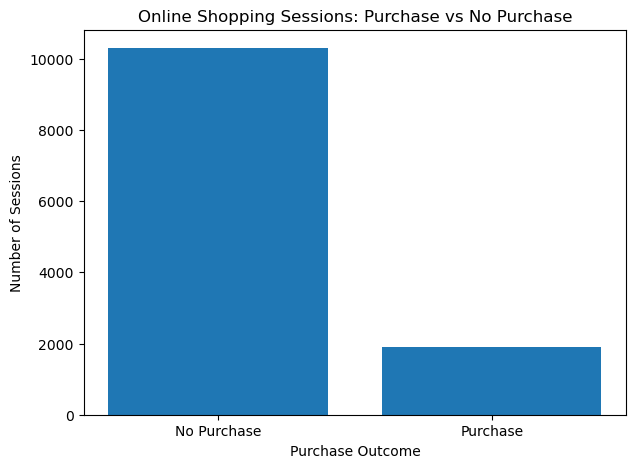

In [14]:
# Count the number of sessions for each purchase outcome
revenue_counts = df_clean["Revenue"].value_counts()

# Create labels for the chart
labels = ["No Purchase", "Purchase"]

# Create a bar chart
plt.figure(figsize=(7, 5))
plt.bar(labels, revenue_counts.values)

# Add chart title and labels
plt.title("Online Shopping Sessions: Purchase vs No Purchase")
plt.xlabel("Purchase Outcome")
plt.ylabel("Number of Sessions")

# Display the chart
plt.show()

In [15]:
# Count the number of sessions for each visitor type
df_clean["VisitorType"].value_counts()

VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

In [16]:
# Count purchases and non-purchases for each visitor type
visitor_purchase = pd.crosstab(
    df_clean["VisitorType"],
    df_clean["Revenue"]
)

# Display the result
visitor_purchase

Revenue,False,True
VisitorType,,
New_Visitor,1271,422
Other,65,16
Returning_Visitor,8961,1470


In [17]:
# Calculate the percentage of visitors who made a purchase
# within each visitor type
visitor_purchase_rate = pd.crosstab(
    df_clean["VisitorType"],
    df_clean["Revenue"],
    normalize="index"
) * 100

# Display the purchase rates
visitor_purchase_rate

Revenue,False,True
VisitorType,,
New_Visitor,75.073833,24.926167
Other,80.246914,19.753086
Returning_Visitor,85.907391,14.092609


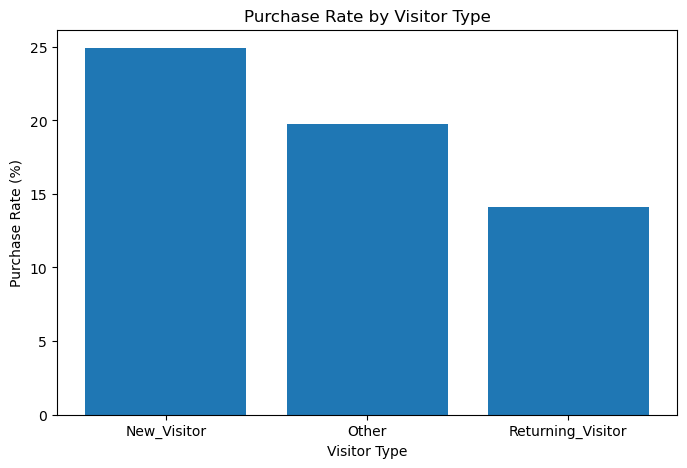

In [18]:
# Calculate the purchase rate for each visitor type
visitor_purchase_rate = pd.crosstab(
    df_clean["VisitorType"],
    df_clean["Revenue"],
    normalize="index"
) * 100

# Select only the percentage of visitors who made a purchase
purchase_rates = visitor_purchase_rate[True]

# Create a bar chart
plt.figure(figsize=(8, 5))
plt.bar(purchase_rates.index, purchase_rates.values)

# Add title and axis labels
plt.title("Purchase Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate (%)")

# Display the chart
plt.show()

In [19]:
# Calculate the average number of product-related pages visited
# for sessions with and without a purchase
product_pages_by_purchase = df_clean.groupby("Revenue")["ProductRelated"].mean()

# Display the results
product_pages_by_purchase

Revenue
False    29.050403
True     48.210168
Name: ProductRelated, dtype: float64

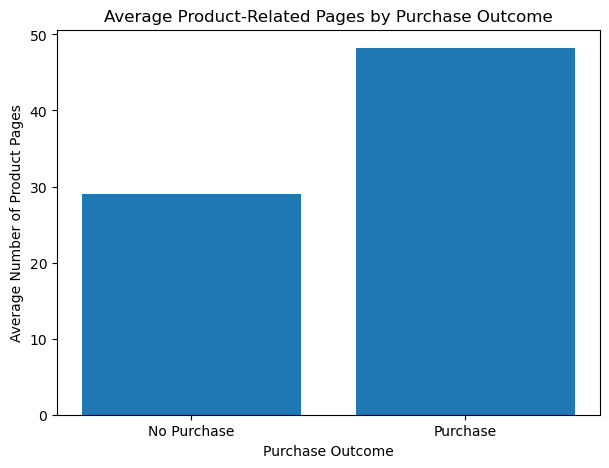

In [20]:
# Create a bar chart showing average product-related pages
# for purchase and non-purchase sessions

plt.figure(figsize=(7, 5))
plt.bar(
    ["No Purchase", "Purchase"],
    product_pages_by_purchase.values
)

# Add title and axis labels
plt.title("Average Product-Related Pages by Purchase Outcome")
plt.xlabel("Purchase Outcome")
plt.ylabel("Average Number of Product Pages")

# Display the chart
plt.show()

In [21]:
# Calculate the average time spent on product-related pages
# for sessions with and without a purchase
product_time_by_purchase = df_clean.groupby("Revenue")["ProductRelated_Duration"].mean()

# Display the results
product_time_by_purchase

Revenue
False    1082.976881
True     1876.209615
Name: ProductRelated_Duration, dtype: float64

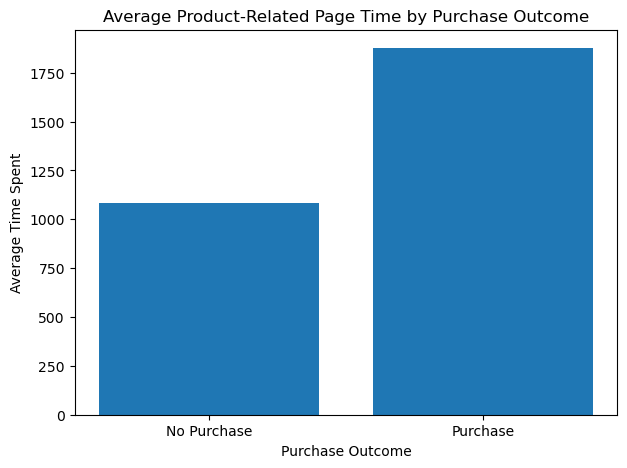

In [22]:
# Create a bar chart showing average time spent
# on product-related pages by purchase outcome

plt.figure(figsize=(7, 5))
plt.bar(
    ["No Purchase", "Purchase"],
    product_time_by_purchase.values
)

# Add title and axis labels
plt.title("Average Product-Related Page Time by Purchase Outcome")
plt.xlabel("Purchase Outcome")
plt.ylabel("Average Time Spent")

# Display the chart
plt.show()

In [23]:
# Calculate the average Page Value for sessions
# with and without a purchase
page_value_by_purchase = df_clean.groupby("Revenue")["PageValues"].mean()

# Display the results
page_value_by_purchase

Revenue
False     1.999985
True     27.264518
Name: PageValues, dtype: float64

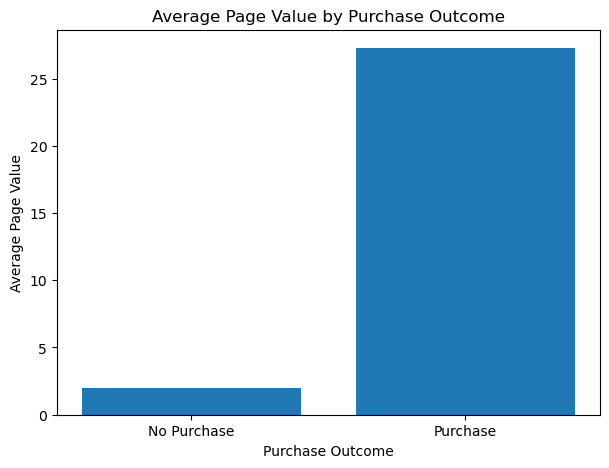

In [24]:
# Create a bar chart showing average Page Value
# for purchase and non-purchase sessions

plt.figure(figsize=(7, 5))
plt.bar(
    ["No Purchase", "Purchase"],
    page_value_by_purchase.values
)

# Add title and axis labels
plt.title("Average Page Value by Purchase Outcome")
plt.xlabel("Purchase Outcome")
plt.ylabel("Average Page Value")

# Display the chart
plt.show()

In [25]:
# Calculate the purchase rate for weekday and weekend sessions
weekend_purchase_rate = pd.crosstab(
    df_clean["Weekend"],
    df_clean["Revenue"],
    normalize="index"
) * 100

# Display the purchase rates
weekend_purchase_rate

Revenue,False,True
Weekend,,
False,84.924032,15.075968
True,82.546345,17.453655


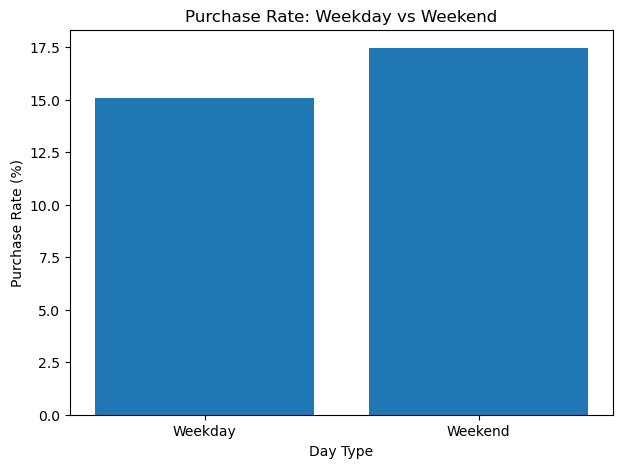

In [26]:
# Select the purchase rate for each day type
weekend_rates = weekend_purchase_rate[True]

# Create a bar chart
plt.figure(figsize=(7, 5))
plt.bar(
    ["Weekday", "Weekend"],
    weekend_rates.values
)

# Add title and axis labels
plt.title("Purchase Rate: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Purchase Rate (%)")

# Display the chart
plt.show()

In [27]:
# Calculate the purchase rate for each month
month_purchase_rate = pd.crosstab(
    df_clean["Month"],
    df_clean["Revenue"],
    normalize="index"
) * 100

# Display the purchase rates
month_purchase_rate

Revenue,False,True
Month,,
Aug,82.448037,17.551963
Dec,87.338804,12.661196
Feb,98.342541,1.657459
Jul,84.722222,15.277778
June,89.824561,10.175439
Mar,89.677419,10.322581
May,89.035746,10.964254
Nov,74.513749,25.486251
Oct,79.052823,20.947177


In [28]:
# Set the correct calendar order for the months
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "June",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Reorder the months using the correct calendar order
month_purchase_rate = month_purchase_rate.reindex(month_order)

# Display the reordered table
month_purchase_rate

Revenue,False,True
Month,,
Jan,NaN,NaN
Feb,98.342541,1.657459
Mar,89.677419,10.322581
Apr,NaN,NaN
May,89.035746,10.964254
June,89.824561,10.175439
Jul,84.722222,15.277778
Aug,82.448037,17.551963
Sep,80.803571,19.196429


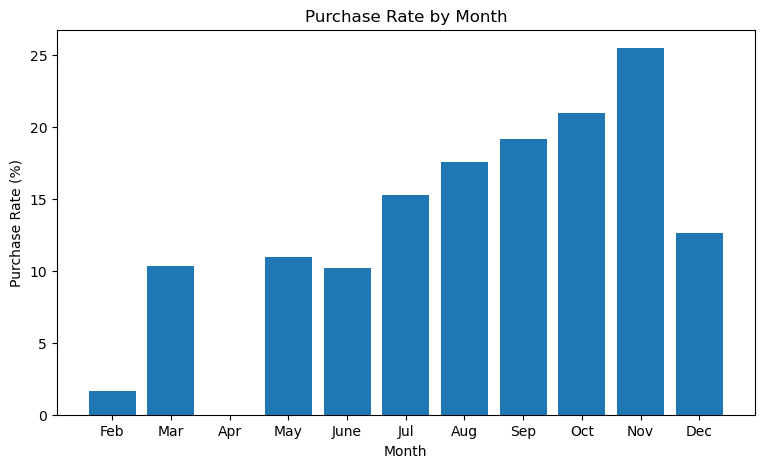

In [29]:
# Select the purchase rate for each month
month_rates = month_purchase_rate[True]

# Create a bar chart
plt.figure(figsize=(9, 5))
plt.bar(month_rates.index, month_rates.values)

# Add title and axis labels
plt.title("Purchase Rate by Month")
plt.xlabel("Month")
plt.ylabel("Purchase Rate (%)")

# Display the chart
plt.show()

In [30]:
# Create the target variable
# Revenue is what we want the model to predict
y = df_clean["Revenue"]

# Create the input features
# Remove Revenue because it is our target
X = df_clean.drop("Revenue", axis=1)

# Display the shapes of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12205, 17)
y shape: (12205,)


In [31]:
# Check the data types of all input features
X.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
dtype: object

In [32]:
# Convert categorical text columns into numerical columns
X_encoded = pd.get_dummies(
    X,
    columns=["Month", "VisitorType"],
    drop_first=True
)

# Display the new shape
print("Original number of features:", X.shape[1])
print("New number of features:", X_encoded.shape[1])

Original number of features: 17
New number of features: 26


In [33]:
# Convert the target variable from True/False to 1/0
y_encoded = y.astype(int)

# Display the first 10 values
y_encoded.head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: Revenue, dtype: int32

In [34]:
# Import the function used to split the dataset
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Display the size of each dataset
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (9764, 26)
Testing data: (2441, 26)


In [51]:
# Import the Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the model
# class_weight="balanced" helps because we have
# fewer purchase sessions than non-purchase sessions
# model = LogisticRegression(
#     max_iter=1000,
#     class_weight="balanced"
# )

# # Train the model using the training data
# model.fit(X_train, y_train)

# print("Model training completed!")

In [36]:
# Create the Logistic Regression model again
# Increase max_iter so the model has more time to converge
model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

# Train the model again
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [37]:
# Use the trained model to predict purchase outcomes
y_pred = model.predict(X_test)

# Display the first 20 predictions
y_pred[:20]

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1])

In [38]:
# Import the accuracy score
from sklearn.metrics import accuracy_score

# Calculate how many predictions were correct
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8701351904956984


In [39]:

# Import tools for detailed model evaluation
from sklearn.metrics import classification_report

# Display precision, recall, and F1-score
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Purchase", "Purchase"]
))

              precision    recall  f1-score   support

 No Purchase       0.95      0.89      0.92      2059
    Purchase       0.56      0.75      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.82      0.78      2441
weighted avg       0.89      0.87      0.88      2441



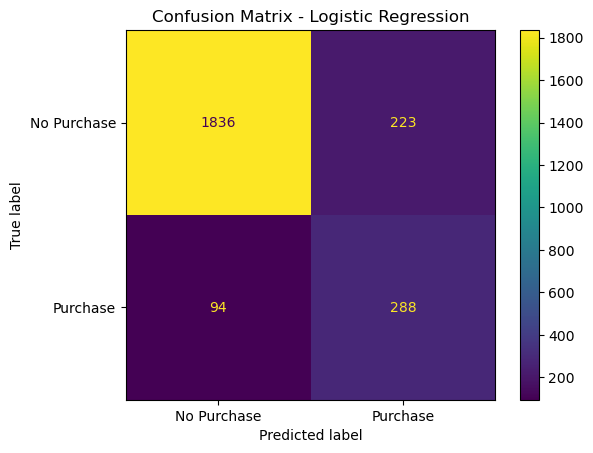

In [40]:
# Import the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Purchase", "Purchase"]
)

disp.plot()

# Add a title
plt.title("Confusion Matrix - Logistic Regression")

# Display the chart
plt.show()

In [41]:
# Import the Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

# Train the model
tree_model.fit(X_train, y_train)

print("Decision Tree training completed!")

Decision Tree training completed!


In [42]:
# Use the Decision Tree to predict purchase outcomes
tree_pred = tree_model.predict(X_test)

# Display the first 20 predictions
tree_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [43]:
# Calculate the Decision Tree accuracy
tree_accuracy = accuracy_score(y_test, tree_pred)

# Display the accuracy
print("Decision Tree Accuracy:", tree_accuracy)

# Display precision, recall, and F1-score
print("\nClassification Report:")
print(classification_report(
    y_test,
    tree_pred,
    target_names=["No Purchase", "Purchase"]
))

Decision Tree Accuracy: 0.862351495288816

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.92      0.92      0.92      2059
    Purchase       0.56      0.55      0.56       382

    accuracy                           0.86      2441
   macro avg       0.74      0.74      0.74      2441
weighted avg       0.86      0.86      0.86      2441



In [44]:
# Import the Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [45]:
# Use the Random Forest model to predict purchase outcomes
rf_pred = random_forest_model.predict(X_test)

# Display the first 20 predictions
rf_pred[:20]

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [46]:
# Calculate the Random Forest accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

# Display the accuracy
print("Random Forest Accuracy:", rf_accuracy)

# Display precision, recall, and F1-score
print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Purchase", "Purchase"]
))

Random Forest Accuracy: 0.9004506349856616

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.92      0.96      0.94      2059
    Purchase       0.74      0.55      0.64       382

    accuracy                           0.90      2441
   macro avg       0.83      0.76      0.79      2441
weighted avg       0.89      0.90      0.89      2441



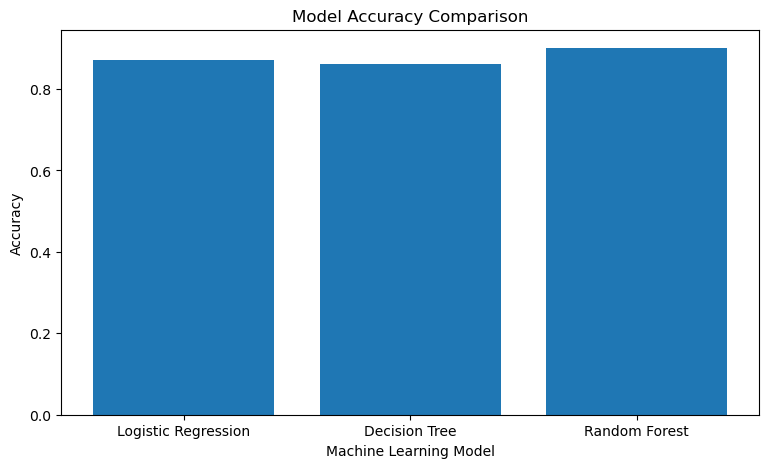

In [47]:
# Store the accuracy of each model
model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

model_accuracies = [
    accuracy,
    tree_accuracy,
    rf_accuracy
]

# Create a bar chart
plt.figure(figsize=(9, 5))
plt.bar(model_names, model_accuracies)

# Add title and labels
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

# Display the chart
plt.show()

In [48]:
# Create a comparison table for all three models
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "Purchase Precision": [
        0.56,
        0.56,
        0.74
    ],
    "Purchase Recall": [
        0.75,
        0.55,
        0.55
    ],
    "Purchase F1": [
        0.65,
        0.56,
        0.64
    ]
})

# Display the comparison table
model_comparison

,Model,Accuracy,Purchase Precision,Purchase Recall,Purchase F1
0,Logistic Regression,0.870135,0.56,0.75,0.65
1,Decision Tree,0.862351,0.56,0.55,0.56
2,Random Forest,0.900451,0.74,0.55,0.64


In [49]:
# Get the importance of each feature from the Random Forest model
feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X_encoded.columns
)

# Sort the features from most important to least important
feature_importance = feature_importance.sort_values(ascending=False)

# Display the 10 most important features
feature_importance.head(10)

PageValues                 0.383565
ExitRates                  0.094124
ProductRelated_Duration    0.091098
ProductRelated             0.065905
BounceRates                0.054480
Administrative_Duration    0.050792
Administrative             0.038349
Month_Nov                  0.030766
TrafficType                0.027619
Region                     0.026405
dtype: float64

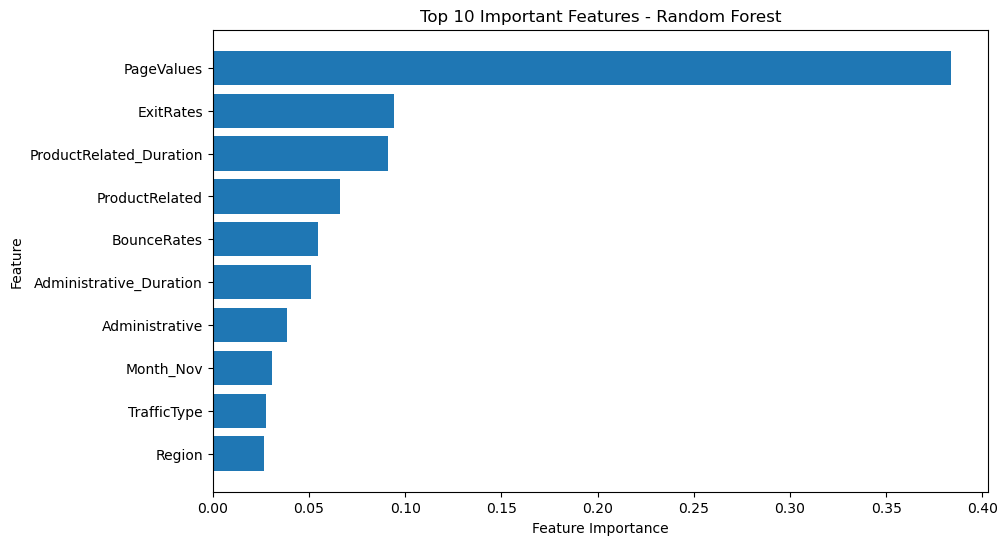

In [50]:
# Select the 10 most important features
top_features = feature_importance.head(10)

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_features.index[::-1], top_features.values[::-1])

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

## Business Insights

Based on the exploratory data analysis and machine learning results, several useful patterns were identified:

* Only **15.63%** of the shopping sessions resulted in a purchase, while **84.37%** did not result in a purchase.
* **New visitors** had a higher purchase rate (**24.93%**) than returning visitors (**14.09%**) in this dataset.
* Visitors who made a purchase viewed more **product-related pages**, averaging **48.21 pages**, compared with **29.05 pages** for visitors who did not purchase.
* Visitors who purchased also spent more time on product-related pages, with an average of **1876.21** compared with **1082.98** for non-purchasing visitors.
* The average **PageValues** was much higher for purchasing sessions (**27.26**) than for non-purchasing sessions (**2.00**).
* The purchase rate was **17.45% on weekends** compared with **15.08% on weekdays**.
* Among the months available in the dataset, **November** had the highest purchase rate at **25.49%**, while **February** had the lowest at **1.66%**.
* In the Random Forest model, **PageValues** was the most important feature, followed by **ExitRates**, **ProductRelated_Duration**, and **ProductRelated**.
* The three machine learning models produced different results. Logistic Regression had **75% purchase recall**, while Random Forest had **74% purchase precision** and **90.05% overall accuracy**.

These findings suggest that website engagement, product-page activity, page value, and visitor characteristics can provide useful information for understanding online purchase behavior. However, these relationships show patterns in the dataset and should not be interpreted as proof that one factor directly causes a purchase.


## Conclusion

This project analyzed online shopping session data to understand and predict whether a visitor would make a purchase.

The analysis showed that purchasing sessions were associated with higher product-page activity, longer time spent on product-related pages, and higher PageValues. The machine learning models also showed that customer session information can be used to predict purchase outcomes.

Three classification models were tested: Logistic Regression, Decision Tree, and Random Forest. Their performance differed across accuracy, precision, recall, and F1-score. This shows that model evaluation should consider multiple performance measures rather than accuracy alone.

Overall, the project demonstrates how data analysis and machine learning can help an e-commerce business understand customer behavior and identify patterns associated with online purchases.
